In [102]:
from pathlib import Path
import gzip
import json
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns
import yaml

In [103]:
sns.set_theme(context="paper", style="ticks")

In [104]:
instance = Instance.from_yaml(Path('../data/anon_14_day_instances/2020-08-27.yaml'))
LC_TO_USD = instance.lc_to_usd
TRUCK_FIXED_COST = instance.truck_fixed_cost

MAX_DEVIATION_POTENTIAL = 12

DEV_POT_BINS = np.linspace(2, 12, 7)
COST_BINS = np.linspace(65, 110, 7)

ZERO_TOL = 1e-8

def currency_formatter(x, pos):
    return f"${x:.0f}"


plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

In [106]:
# get data from instances
data_path = Path("../data/anon_14_day_instances")
all_instances = list(data_path.glob("aggregate_instance_*.yaml"))

idx_to_n_farmers = {}
idx_to_n_ints = {}

for file in all_instances:
    instance = Instance.from_yaml(file)
    id = int(file.name[:-5].split("_")[-1])
    n_farmers = len(instance.farmers)
    n_intermediaries = len(instance.intermediaries)

    idx_to_n_farmers[id - 1] = n_farmers
    idx_to_n_ints[id - 1] = n_intermediaries

In [107]:
root = Path("../results/exp_4_heuristic")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"

data = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        payload = json.load(f)

    metadata = payload["experiment_metadata"]

    if payload["completed"] is False:
        row = {
            "job_id": metadata["job_id"],
            "n_farmers": idx_to_n_farmers[metadata["job_id"] % 14],
            "n_intermediaries": idx_to_n_ints[metadata["job_id"] % 14],
            "opt_gap": None,
            "time_heuristic": None,
        }
    else:
        summary = payload["run"]["summary"]
        snapshot = summary["instance_snapshot"]
        farmers = snapshot["farmers"]
        intermediaries = snapshot["intermediaries"]

        row = {
            "job_id": metadata["job_id"],
            "n_farmers": len(farmers),
            "n_intermediaries": len(intermediaries),
            "opt_gap": summary["rel_gap"],
            "time_heuristic": summary["total_time"],
        }

    data.append(row)

df = pd.DataFrame(data)


In [58]:
root = Path("../results/exp_4_exact")
all_jsons = list(root.rglob("*.json.gz"))

data_2 = []

for file in all_jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        payload = json.load(f)

    metadata = payload["experiment_metadata"]

    summary = payload["runs"][0]["summary_vanilla"]

    snapshot = summary["instance_snapshot"]

    farmers = snapshot["farmers"]
    intermediaries = snapshot["intermediaries"]

    row = {
        "job_id": metadata["job_id"],
        "n_farmers": len(farmers),
        "n_intermediaries": len(intermediaries),
        "opt_gap": summary["rel_gap"],
        "time_exact": summary["total_time"],
    }

    data_2.append(row)

df_2 = pd.DataFrame(data_2)

KeyError: 'runs'

In [77]:
df_joint = pd.concat([df])

In [101]:
df_joint.iloc[df_joint.opt_gap.argmax()]

job_id              182.000000
n_farmers            25.000000
n_intermediaries     14.000000
opt_gap               0.586038
time_heuristic       21.138918
Name: 133, dtype: float64

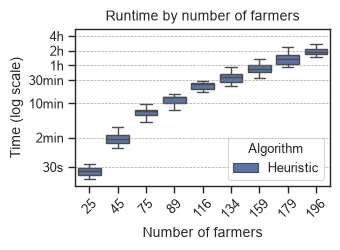

In [91]:
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

time_data_melted = df_joint.melt(
    id_vars='n_farmers',
    value_vars=['time_heuristic'],
    var_name='Time Type',
    value_name='Time'
)

time_data_filtered = (
    time_data_melted
    .query("n_farmers <= 196")
    .copy()
)

# seconds -> hours
time_data_filtered['Time'] = time_data_filtered['Time'] / 3600

plt.figure(figsize=(3.5, 2.6))

ax = sns.boxplot(
    data=time_data_filtered,
    x='n_farmers',
    y='Time',
    hue='Time Type',
    showfliers=False
)

# Logarithmic y-axis
ax.set_yscale('log')

# Tick positions are in HOURS
ticks = [
    30 / 3600,   # 30 sec
    2 / 60,      # 2 min
    10 / 60,     # 10 min
    30 / 60,     # 30 min
    1,
    2,           # 2 h
    4            # 4 h
]

tick_labels = [
    '30s',
    '2min',
    '10min',
    '30min',
    '1h',
    '2h',
    '4h'
]

# Horizontal grid lines
for tick in ticks:
    ax.axhline(
        y=tick,
        color='gray',
        linestyle='--',
        linewidth=0.5,
        alpha=0.7
    )

# Custom ticks
ax.yaxis.set_minor_locator(FixedLocator([]))
ax.yaxis.set_major_locator(FixedLocator(ticks))
ax.yaxis.set_major_formatter(FixedFormatter(tick_labels))

ax.set_title('Runtime by number of farmers')
ax.set_xlabel('Number of farmers')
ax.set_ylabel('Time (log scale)')

# Legend
handles, legend_labels = ax.get_legend_handles_labels()

legend_labels = [
    'Heuristic' if label == 'time_heuristic'
    else 'Exact' if label == 'time_exact'
    else label
    for label in legend_labels
]

ax.legend(
    handles,
    legend_labels,
    title='Algorithm',
    loc='lower right'
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

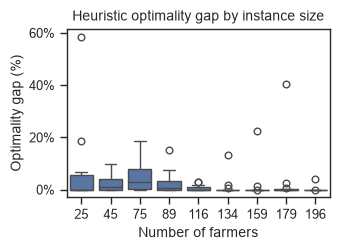

In [95]:
from matplotlib.ticker import PercentFormatter

gap_data_filtered = df.query("n_farmers <= 196")

# Create the boxplot for opt_gap
plt.figure(figsize=(3.5, 2.6))
sns.boxplot(data=gap_data_filtered, x='n_farmers', y='opt_gap', showfliers=True)

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))

plt.title('Heuristic optimality gap by instance size')
plt.xlabel('Number of farmers')
plt.ylabel('Optimality gap (%)')
plt.tight_layout()
plt.show()